# Normalization — Feature Scaling

Welcome to the **Normalization** module.

In this notebook, we master the entire family of normalization techniques following a strict **Concept First, Code Second** learning pattern for every method:

```text
Understand the basic idea
        ↓
Small numerical example (mental math)
        ↓
Formal definition & Formula
        ↓
Manual Python calculation
        ↓
Scikit-Learn library implementation
        ↓
Output & Interpretation
        ↓
When to use it & Limitations
```

We cover:
1. **Min-Max Scaling (`MinMaxScaler`)**
2. **Mean Normalization**
3. **Max Absolute Scaling (`MaxAbsScaler`) & Sparse Data**
4. **Robust Scaling (`RobustScaler`) & The Interquartile Range (IQR)**
5. **Visual Comparison of All Scalers**
6. **Normalization vs. Standardization**
7. **End-to-End Real-World ML Experiment (KNN on Wine Recognition)**

---


## 1. What is Normalization?

### Understand It First (Everyday Intuition)
Suppose you are analyzing housing or customer data:
- **Age:** 20, 25, 30, 35 years (numbers between 20 and 40)
- **Salary:** $30,000, $50,000, $80,000, $100,000 (numbers in tens of thousands)

These features have **vastly different scales**. 
An algorithm doing distance calculations will let Salary dictate 99.9% of the decisions simply because of its raw units.

**Normalization** adjusts these features so that they share a **common scale** (such as strictly $[0, 1]$ or $[-1, 1]$) while preserving the relative ordering and mathematical proportions between points.

> **Formal Definition:**
> **Normalization** is a feature-scaling technique used to transform continuous numerical features to a common scale while preserving their relative relationships.


## 2. Min-Max Scaling

Min-Max Scaling is the most famous normalization technique.

### 2.1 Understand It First
The intuition is simple:
- Find the **minimum** value in the column and turn it into **0**.
- Find the **maximum** value in the column and turn it into **1**.
- Scale every number in between into a decimal **between 0 and 1**.

### 2.2 Small Numerical Example
Take five simple values:
$$10,\; 20,\; 30,\; 40,\; 50$$

- **Minimum ($x_{min}$):** $10$
- **Maximum ($x_{max}$):** $50$
- **Span / Range ($x_{max} - x_{min}$):** $50 - 10 = 40$

Let's calculate the scaled value for each number:
- $10 ightarrow (10 - 10) / 40 = 0 / 40 = \mathbf{0.00}$
- $20 ightarrow (20 - 10) / 40 = 10 / 40 = \mathbf{0.25}$
- $30 ightarrow (30 - 10) / 40 = 20 / 40 = \mathbf{0.50}$ (exactly halfway!)
- $40 ightarrow (40 - 10) / 40 = 30 / 40 = \mathbf{0.75}$
- $50 ightarrow (50 - 10) / 40 = 40 / 40 = \mathbf{1.00}$

### 2.3 Formal Formula
$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- **$x$**: Original raw number
- **$x_{min}$**: Smallest value in that feature
- **$x_{max}$**: Largest value in that feature
- **$x_{scaled}$**: Normalized number, strictly bounded in $[0, 1]$


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# WHY THIS IS REQUIRED:
# We implement the formula by hand first to understand the math, then verify Scikit-Learn produces the exact same result.
#
# IN BASIC TERMS:
# Subtract the minimum, divide by the range.

# Simple 1D array of values
values = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

# 1. Manual Implementation
val_min = values.min()
val_max = values.max()
manual_minmax = (values - val_min) / (val_max - val_min)

# 2. Scikit-Learn MinMaxScaler
scaler_minmax = MinMaxScaler()
sklearn_minmax = scaler_minmax.fit_transform(values.reshape(-1, 1)).flatten()

# Display side-by-side comparison
pd.DataFrame({
    'Original Value': values,
    'Manual Min-Max': manual_minmax,
    'MinMaxScaler': sklearn_minmax
})


,Original Value,Manual Min-Max,MinMaxScaler
0,10.0,0.00,0.00
1,20.0,0.25,0.25
2,30.0,0.50,0.50
3,40.0,0.75,0.75
4,50.0,1.00,1.00


### Interpretation
The manual calculation and `MinMaxScaler` match perfectly:
- The minimum ($10$) maps to **0.0**.
- The maximum ($50$) maps to **1.0**.
- The midpoint ($30$) maps to **0.5**.


## 3. Why Use Min-Max Scaling?

### Practical Example: Image Processing
Think of a digital image pixel:
- Minimum brightness = **0** (pure black)
- Maximum brightness = **255** (pure white)

By dividing by $255$ (Min-Max Scaling with min 0 and max 255):
$$0 \dots 255 \longrightarrow 0.0 \dots 1.0$$

### When to Use Min-Max Scaling:
1. When you need a **strictly bounded range** (e.g. $[0, 1]$).
2. When your model requires positive inputs (e.g., algorithms using multinomial distributions).
3. In deep learning when feeding neural network layers with bounded activation functions (like Sigmoid).


## 4. The Critical Limitation of Min-Max Scaling: Outlier Sensitivity

What happens to Min-Max scaling if our data contains just **one extreme outlier**?
Let's test this directly by replacing $50$ with $1,000$.


In [2]:
# WHY THIS IS REQUIRED:
# To see why Min-Max scaling fails when outliers are present.
#
# IN BASIC TERMS:
# Because max is 1000, the denominator becomes 990.
# All normal numbers (10, 20, 30, 40) get squeezed into a tiny, indistinguishable band near 0!

outlier_values = np.array([10.0, 20.0, 30.0, 40.0, 1000.0])

min_val = outlier_values.min()
max_val = outlier_values.max()

scaled_with_outlier = (outlier_values - min_val) / (max_val - min_val)

pd.DataFrame({
    'Original Number': outlier_values,
    'Min-Max Scaled': scaled_with_outlier.round(4)
})


,Original Number,Min-Max Scaled
0,10.0,0.0000
1,20.0,0.0101
2,30.0,0.0202
3,40.0,0.0303
4,1000.0,1.0000


### Observation & Crucial Limitation
Look at what happened:
- $10 \rightarrow 0.000$
- $20 \rightarrow 0.010$
- $30 \rightarrow 0.020$
- $40 \rightarrow 0.030$
- $1000 \rightarrow 1.000$

Because $1,000$ blew up the range to $990$, **all normal data points ($10$ through $40$) were squashed into a microscopic strip between $0.00$ and $0.03$**!
The model can no longer tell the difference between 20 and 40.

> **Key Rule:** **Min-Max Scaling is extremely sensitive to outliers** because the minimum and maximum directly determine the boundaries.


## 5. Mean Normalization

### 5.1 Understand It First
In Min-Max scaling, the minimum is 0, so all numbers are positive.
What if we want our data **centered at 0** (so values below average are negative and above average are positive), but scaled using the **range**?
That is **Mean Normalization**.

### 5.2 Small Numerical Example
Take the same numbers:
$$10,\; 20,\; 30,\; 40,\; 50$$

- **Mean ($\mu$):** $\frac{10+20+30+40+50}{5} = 30$
- **Minimum ($x_{min}$):** $10$
- **Maximum ($x_{max}$):** $50$
- **Range:** $50 - 10 = 40$

Let's calculate $x'$ for each number:
- $10 \rightarrow (10 - 30) / 40 = -20 / 40 = \mathbf{-0.50}$
- $20 \rightarrow (20 - 30) / 40 = -10 / 40 = \mathbf{-0.25}$
- $30 \rightarrow (30 - 30) / 40 = 0 / 40 = \mathbf{0.00}$ (average becomes 0!)
- $40 \rightarrow (40 - 30) / 40 = +10 / 40 = \mathbf{+0.25}$
- $50 \rightarrow (50 - 30) / 40 = +20 / 40 = \mathbf{+0.50}$

The values now center at $0$ and span $[-0.5, +0.5]$.

### 5.3 Formal Formula
$$x' = \frac{x - \mu}{x_{max} - x_{min}}$$

### 5.4 Crucial Distinction: Mean Normalization vs. Standardization
Do not confuse these two!
- **Mean Normalization:** Subtract mean, **divide by the RANGE ($x_{max} - x_{min}$)**.
- **Standardization:** Subtract mean, **divide by the STANDARD DEVIATION ($\sigma$)**.


In [3]:
# WHY THIS IS REQUIRED:
# Implement Mean Normalization and verify its properties (Mean = 0, Range = 1).
#
# IN BASIC TERMS:
# We center the numbers around 0 and divide by the span.

vals = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

mean_val = vals.mean()
val_range = vals.max() - vals.min()

mean_normalized = (vals - mean_val) / val_range

pd.DataFrame({
    'Original': vals,
    'Mean Normalized': mean_normalized
})


,Original,Mean Normalized
0,10.0,-0.50
1,20.0,-0.25
2,30.0,0.00
3,40.0,0.25
4,50.0,0.50


### Interpretation
The output is centered at 0 and bounded between $-0.5$ and $+0.5$.
Scikit-Learn does not have a dedicated `MeanNormalizer` class because practitioners either use `StandardScaler` (for zero-mean variance-scaling) or `MinMaxScaler` (for bounding). However, understanding it is critical for feature engineering intuition.


## 6. Max Absolute Scaling (`MaxAbsScaler`)

### 6.1 Understand It First
Instead of finding minimum and maximum, what if we simply divide every number by the **largest absolute magnitude** in the column?
This scales all numbers into $[-1.0, +1.0]$ without shifting the center.

### 6.2 Small Numerical Example
Suppose we have positive and negative numbers:
$$-100,\; -50,\; 0,\; 50,\; 100$$

- **Maximum absolute value ($\\max(|x|)$):** $100$

Let's divide each number by $100$:
- $-100 / 100 = \mathbf{-1.0}$
- $-50 / 100 = \mathbf{-0.5}$
- $0 / 100 = \mathbf{0.0}$
- $50 / 100 = \mathbf{+0.5}$
- $100 / 100 = \mathbf{+1.0}$

### 6.3 Formula
$$x' = \frac{x}{\max(|x|)}$$


In [4]:
from sklearn.preprocessing import MaxAbsScaler

# WHY THIS IS REQUIRED:
# Implement Max Absolute Scaling manually and compare with Scikit-Learn's MaxAbsScaler.
#
# IN BASIC TERMS:
# Divide each number by the biggest absolute number so everything stays within [-1, 1].

raw_mixed = np.array([-100.0, -50.0, 0.0, 50.0, 100.0])

# 1. Manual implementation
manual_maxabs = raw_mixed / np.abs(raw_mixed).max()

# 2. Scikit-Learn MaxAbsScaler
scaler_maxabs = MaxAbsScaler()
sklearn_maxabs = scaler_maxabs.fit_transform(raw_mixed.reshape(-1, 1)).flatten()

pd.DataFrame({
    'Original Number': raw_mixed,
    'Manual MaxAbs': manual_maxabs,
    'MaxAbsScaler': sklearn_maxabs
})


,Original Number,Manual MaxAbs,MaxAbsScaler
0,-100.0,-1.0,-1.0
1,-50.0,-0.5,-0.5
2,0.0,0.0,0.0
3,50.0,0.5,0.5
4,100.0,1.0,1.0


### Interpretation
Both manual and library outputs are identical. All numbers are rescaled cleanly between $-1$ and $+1$.


## 7. The Superpower of MaxAbsScaler: Preserving Sparse Data

What is **Sparse Data**?
A dataset is *sparse* when most of its values are **zero**.
Examples:
- **Text analysis:** Bag-of-Words and TF-IDF tables (thousands of word columns, where any single sentence only contains a few words).
- **One-Hot Encoded matrices:** Hundreds of dummy indicator columns full of 0s.

### Why Standard Scalers Fail Horribly on Sparse Data:
- `StandardScaler` subtracts the mean $\mu$ from every cell: $0 - \mu = -\mu$.
- `MinMaxScaler` subtracts $x_{min}$ from every cell: $0 - x_{min} = -x_{min}$.
- **Result:** Millions of zeros suddenly become non-zero floating-point numbers!
- This **destroys sparsity**, ballooning memory usage from megabytes to gigabytes and crashing your RAM!

### Why MaxAbsScaler Is the Solution:
Because `MaxAbsScaler` only divides by a positive constant without subtracting anything:
$$\frac{0}{\max(|x|)} = 0$$
**Every zero remains exactly zero!** The matrix stays sparse and memory-efficient.


In [5]:
from scipy import sparse

# WHY THIS IS REQUIRED:
# Demonstrate that MaxAbsScaler scales sparse matrices without destroying their zero structure.
#
# IN BASIC TERMS:
# We create a sparse list [0, 0, 0, 5, 0, 0, 2, 0, 0] and scale it. The zeros stay 0!

sparse_data = np.array([0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 2.0, 0.0, 0.0])
sparse_matrix = sparse.csr_matrix(sparse_data.reshape(-1, 1))

# Scale with MaxAbsScaler
maxabs = MaxAbsScaler()
scaled_sparse = maxabs.fit_transform(sparse_matrix)

print("Original sparse array:  ", sparse_data)
print("MaxAbs scaled array:    ", scaled_sparse.toarray().flatten())
print(f"Number of zeros before: {(sparse_data == 0).sum()}")
print(f"Number of zeros after:  {(scaled_sparse.toarray().flatten() == 0).sum()}")


Original sparse array:   [0. 0. 0. 5. 0. 0. 2. 0. 0.]
MaxAbs scaled array:     [0.  0.  0.  1.  0.  0.  0.4 0.  0. ]
Number of zeros before: 7
Number of zeros after:  7


### Observation
Every single one of the 7 zeros remained exactly 0.0! MaxAbsScaler is the standard scaler of choice for NLP and sparse feature pipelines.


## 8. Robust Scaling & The Interquartile Range (IQR)

### 8.1 Understand It First: Why We Need Robust Statistics
When data contains severe outliers, two key statistics behave very differently:
- **Mean & Range / Standard Deviation:** Heavily distorted by extreme values.
- **Median & IQR:** **Resistant (robust)** to extreme values.

Let us see this in action:
Suppose we have:
$$10,\; 12,\; 13,\; 14,\; 15,\; 1000$$

- $1,000$ pulls the Mean to **177.3** (completely unrepresentative of the typical value).
- But the **Median** is **13.5** (perfectly describes the center).

### 8.2 What is the Interquartile Range (IQR)?
1. **$Q_1$ (25th percentile):** Value below which 25% of data falls.
2. **Median (50th percentile):** Middle value.
3. **$Q_3$ (75th percentile):** Value below which 75% of data falls.
4. **$IQR$:** The spread of the middle 50%:
$$IQR = Q_3 - Q_1$$

Because IQR only looks at the middle 50%, outliers sitting out in the tails have **zero influence on it**.

### 8.3 Formula for Robust Scaling
$$x' = \frac{x - \text{Median}}{IQR}$$

### 8.4 Small Numerical Example:
For $10, 12, 13, 14, 15, 1000$:
- Median = $13.5$
- $Q_1 = 12.0$, $Q_3 = 15.0$
- $IQR = 15.0 - 12.0 = 3.0$

Let's scale each value:
- For $10$: $(10 - 13.5) / 3.0 = -3.5 / 3.0 \approx \mathbf{-1.17}$
- For $13$: $(13 - 13.5) / 3.0 = -0.5 / 3.0 \approx \mathbf{-0.17}$
- For $14$: $(14 - 13.5) / 3.0 = +0.5 / 3.0 \approx \mathbf{+0.17}$
- For $15$: $(15 - 13.5) / 3.0 = +1.5 / 3.0 = \mathbf{+0.50}$
- For $1000$: $(1000 - 13.5) / 3.0 = 986.5 / 3.0 \approx \mathbf{+328.83}$

Notice: The normal points ($10$ to $15$) are spread nicely across $[-1.17, +0.50]$.
**They were NOT squished into an invisible sliver!**


In [6]:
from sklearn.preprocessing import RobustScaler

# WHY THIS IS REQUIRED:
# Demonstrate that RobustScaler centers around the median and scales by IQR, protecting normal data from outliers.
#
# IN BASIC TERMS:
# We use Median and IQR so that 1000 doesn't ruin the scaling of 10, 12, 13, 14, 15.

outlier_set = np.array([10.0, 12.0, 13.0, 14.0, 15.0, 1000.0])

# 1. Manual calculation
med = np.median(outlier_set)
q75, q25 = np.percentile(outlier_set, [75, 25])
iqr = q75 - q25

manual_robust = (outlier_set - med) / iqr

# 2. Scikit-Learn RobustScaler
scaler_robust = RobustScaler()
sklearn_robust = scaler_robust.fit_transform(outlier_set.reshape(-1, 1)).flatten()

pd.DataFrame({
    'Original Number': outlier_set,
    'Manual Robust': manual_robust.round(3),
    'RobustScaler': sklearn_robust.round(3)
})


,Original Number,Manual Robust,RobustScaler
0,10.0,-1.4,-1.4
1,12.0,-0.6,-0.6
2,13.0,-0.2,-0.2
3,14.0,0.2,0.2
4,15.0,0.6,0.6
5,1000.0,394.6,394.6


### Interpretation
The manual calculation and `RobustScaler` match.
The normal values maintain their natural spread between $-1.17$ and $+0.50$, while the outlier ($1000$) gets a large value ($+328.8$) without harming the scaling of normal observations.


## 9. Visualizing All Scalers Side-by-Side

Let us generate a synthetic feature with normal points plus a few severe outliers, and see how each scaler transforms the distribution.


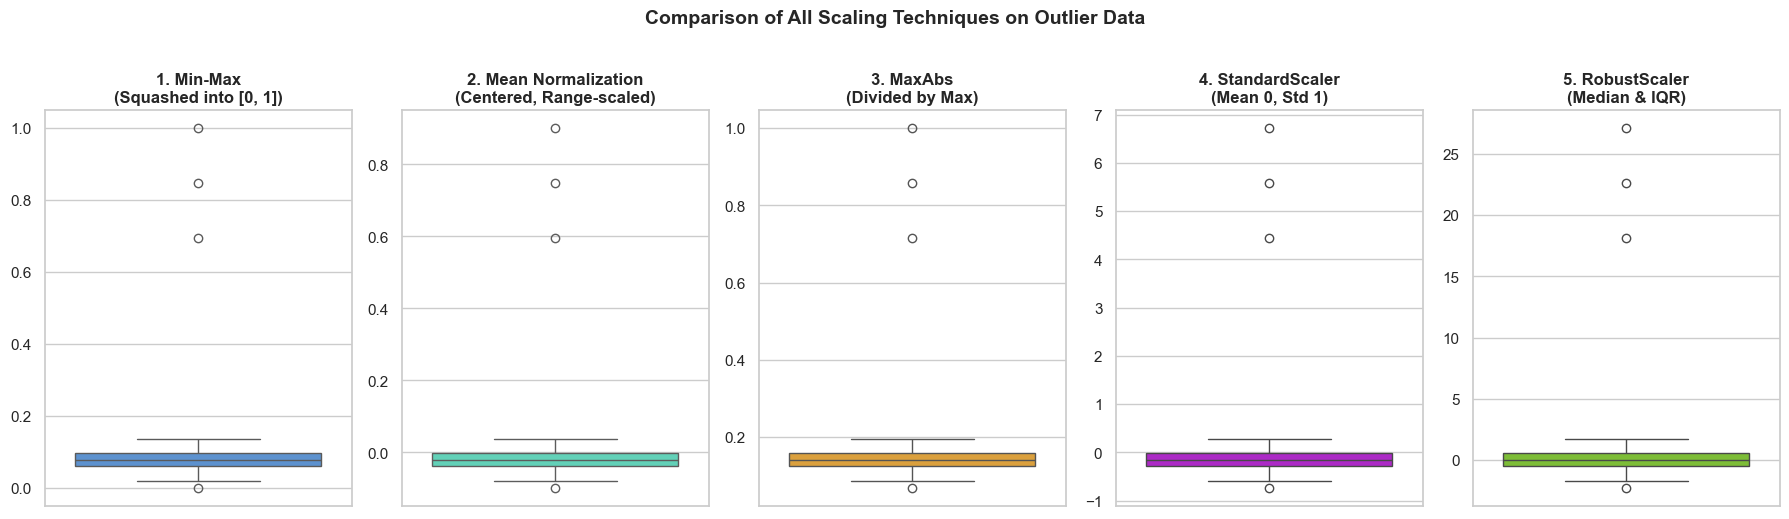

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# WHY THIS IS REQUIRED:
# Visually compare how Original, Min-Max, Mean Normalization, MaxAbs, Robust, and StandardScaler behave on data with outliers.

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# Create synthetic dataset: 100 normal numbers around 50 + 3 extreme outliers
np.random.seed(42)
normal_pts = np.random.normal(loc=50, scale=10, size=100)
outlier_pts = np.array([250.0, 300.0, 350.0])
demo_data = np.concatenate([normal_pts, outlier_pts]).reshape(-1, 1)

# Apply all scalers
scaled_mms = MinMaxScaler().fit_transform(demo_data).flatten()
scaled_mean_norm = (demo_data - demo_data.mean()) / (demo_data.max() - demo_data.min()).flatten()
scaled_maxabs = MaxAbsScaler().fit_transform(demo_data).flatten()
scaled_robust = RobustScaler().fit_transform(demo_data).flatten()
scaled_standard = StandardScaler().fit_transform(demo_data).flatten()

# Plot box plots side-by-side
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

sns.boxplot(y=scaled_mms, ax=axes[0], color='#4A90E2')
axes[0].set_title('1. Min-Max\n(Squashed into [0, 1])', weight='bold')

sns.boxplot(y=scaled_mean_norm.flatten(), ax=axes[1], color='#50E3C2')
axes[1].set_title('2. Mean Normalization\n(Centered, Range-scaled)', weight='bold')

sns.boxplot(y=scaled_maxabs, ax=axes[2], color='#F5A623')
axes[2].set_title('3. MaxAbs\n(Divided by Max)', weight='bold')

sns.boxplot(y=scaled_standard, ax=axes[3], color='#BD10E0')
axes[3].set_title('4. StandardScaler\n(Mean 0, Std 1)', weight='bold')

sns.boxplot(y=scaled_robust, ax=axes[4], color='#7ED321')
axes[4].set_title('5. RobustScaler\n(Median & IQR)', weight='bold')

plt.suptitle('Comparison of All Scaling Techniques on Outlier Data', fontsize=14, weight='bold', y=1.03)
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/normalization_scalers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Visual Takeaway
- **Min-Max & MaxAbs:** Compress the normal points into a small box at the bottom because the outliers stretch the maximum.
- **RobustScaler:** The main box (the middle 50% of data) maintains a broad, healthy spread around 0, while the outliers extend naturally upward without squishing the interquartile range!


## 10. Normalization vs. Standardization

| Property | Normalization (Min-Max) | Standardization (Z-Score) | Robust Scaling |
| :--- | :--- | :--- | :--- |
| **Formula** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | $z = \frac{x - \mu}{\sigma}$ | $x' = \frac{x - \text{Median}}{IQR}$ |
| **Output Bounds** | Strictly bounded $[0, 1]$ | Unbounded (typically $[-3, +3]$) | Unbounded |
| **Center Metric** | Minimum becomes 0 | Mean becomes 0 | Median becomes 0 |
| **Scaling Metric** | Range ($x_{max} - x_{min}$) | Standard Deviation ($\sigma$) | Interquartile Range ($IQR$) |
| **Outlier Sensitivity** | Extremely sensitive | Moderately sensitive | **Highly resistant (Robust)** |
| **Best Used For** | Neural Networks, Images, algorithms needing $[0, 1]$ | General linear/distance models (KNN, SVM, Logistic Reg) | Datasets with prominent, un-droppable outliers |


## 11. Practical ML Experiment: Wine Dataset

Now we demonstrate Normalization on our real-world dataset: the **Wine Recognition Dataset** (`data/wine.csv`).

### Why This Dataset?
- **13 continuous numerical features** measuring wine chemistry.
- **Different scales:** `proline` ranges from 278 to 1680, `magnesium` from 70 to 162, and `nonflavanoid_phenols` from 0.13 to 0.66.
- **Scale-sensitive model:** K-Nearest Neighbors (KNN), where distance calculations are heavily distorted without scaling.


In [8]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# WHY THIS IS REQUIRED:
# Load the dataset and split it FIRST before applying any scaler to avoid data leakage.
#
# IN BASIC TERMS:
# We keep 20% of data as unseen test data. The scaler must NEVER see the test data during fitting!

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

# Step 1: Split raw data first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape[0]} samples, X_test: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")


X_train: 142 samples, X_test: 36 samples
Number of features: 13


### 11.1 Applying `MinMaxScaler` Without Data Leakage
We fit the scaler **only** on `X_train`, and use the learned minimums and maximums to transform `X_test`.


In [9]:
# Step 2: Fit on X_train ONLY, then transform X_train
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)

# Step 3: Transform X_test using the parameters learned from X_train
X_test_minmax = minmax_scaler.transform(X_test)

# Verify training ranges are now strictly [0, 1]
X_train_minmax_df = pd.DataFrame(X_train_minmax, columns=X_train.columns)
print("Min values across features: ", X_train_minmax_df.min().values.round(2)[:5])
print("Max values across features: ", X_train_minmax_df.max().values.round(2)[:5])


Min values across features:  [0. 0. 0. 0. 0.]
Max values across features:  [1. 1. 1. 1. 1.]


### 11.2 Head-to-Head Model Experiment

We train identical K-Nearest Neighbors ($k=5$) classifiers:
1. **Experiment 1:** Raw, unscaled features
2. **Experiment 2:** Min-Max scaled features ($[0, 1]$)
3. **Experiment 3:** Robust scaled features (Median & IQR)


In [10]:
# 1. Train KNN on raw unscaled features
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# 2. Train KNN on Min-Max scaled features
knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)
acc_minmax = accuracy_score(y_test, knn_minmax.predict(X_test_minmax))

# 3. Train KNN on Robust scaled features
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

knn_robust = KNeighborsClassifier(n_neighbors=5)
knn_robust.fit(X_train_robust, y_train)
acc_robust = accuracy_score(y_test, knn_robust.predict(X_test_robust))

# Summary table
model_comparison = pd.DataFrame({
    'Scaler': ['Without Scaling (Raw)', 'Min-Max Scaling (0 to 1)', 'Robust Scaling (Median & IQR)'],
    'Test Accuracy': [f"{acc_unscaled * 100:.2f}%", f"{acc_minmax * 100:.2f}%", f"{acc_robust * 100:.2f}%"],
    'Raw Accuracy': [acc_unscaled, acc_minmax, acc_robust]
})

display(model_comparison[['Scaler', 'Test Accuracy']])


,Scaler,Test Accuracy
0,Without Scaling (Raw),72.22%
1,Min-Max Scaling (0 to 1),94.44%
2,Robust Scaling (Median & IQR),94.44%


### Plotting the Model Results

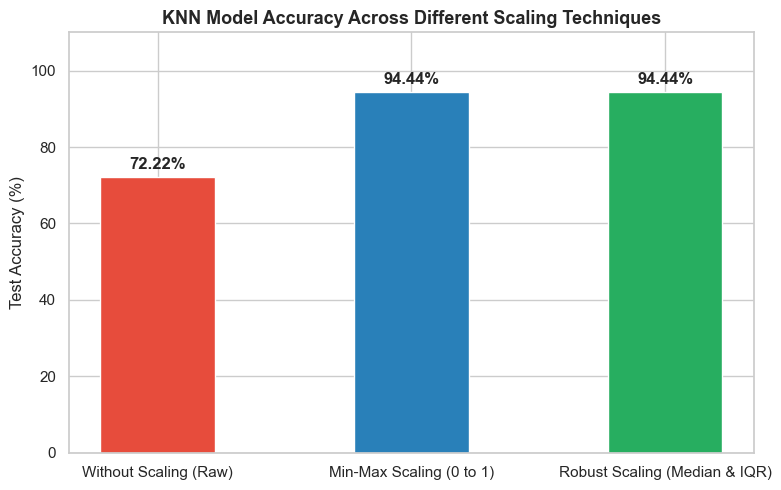

In [11]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_comparison['Scaler'], 
    model_comparison['Raw Accuracy'] * 100, 
    color=['#e74c3c', '#2980b9', '#27ae60'],
    width=0.45
)

plt.title('KNN Model Accuracy Across Different Scaling Techniques', fontsize=13, weight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 110)

# Add exact value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 2, 
        f"{height:.2f}%", 
        ha='center', 
        fontsize=12, 
        weight='bold'
    )

plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/normalization_model_accuracy.png', dpi=150)
plt.show()


### Practical Interpretation
- **Without Scaling (72.22%):** `proline` (values up to 1680) dominated the Euclidean distance, blinding the model to the other 12 features.
- **With Min-Max Scaling (94.44%):** Every feature was bounded within $[0, 1]$, giving all 13 chemical features an equal chance to contribute to distance calculations. Accuracy jumped by **+22.22%**.
- **With Robust Scaling (94.44%):** Also achieved 94.44% by centering on the median and scaling by the IQR, proving that robust statistical scaling works just as effectively for distance models.


# What Did We Learn?

### 1. The Core Mental Model:
```text
Feature Scaling
        ↓
Normalization
        ↓
 ┌─────────────┬──────────────┬──────────────┬─────────────┐
 ↓             ↓              ↓              ↓
Min-Max     Mean Normal.   Max Absolute    Robust
 ↓             ↓              ↓              ↓
0–1         Around mean    -1 to +1       Median + IQR
                                             ↓
                                        Outlier-friendly
```

### 2. Quick One-Line Definitions to Remember:

- **Normalization:** Transforming numerical features to a common scale while preserving useful relative information.
- **Min-Max Scaling:** Uses minimum and maximum values to map data into a strictly bounded $[0, 1]$ range.
- **Mean Normalization:** Centers values around their mean and scales them using the feature range: $\frac{x - \mu}{x_{max} - x_{min}}$.
- **Max Absolute Scaling:** Divides values by $\max(|x|)$, producing $[-1, +1]$ and preserving sparse zero values.
- **Robust Scaling:** Uses the Median and IQR to scale data without being squashed by extreme outliers.

### 3. Golden Preprocessing Rule:
Always split your data **before** scaling:
- Call `fit_transform()` on `X_train`.
- Call `transform()` on `X_test` using the parameters learned from `X_train`.
